# Chapter 5 - Elements of Differential Geometry

Standalone computational companion for printed pages 109-130, PDF pages 119-140. The chapter question is: what extra structure lets local tangent planes assemble into curved geometry?

## 1. Tangent Spaces

A tangent space is the local linear arena at a point. A tangent vector may appear as an arrow, a directional derivative operator, or, on a statistical model, a score random variable. These are representations of one geometric object.

In [1]:
from pathlib import Path
import json, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Image, HTML, JSON, display
HERE=Path.cwd()
BOOK_ROOT=next(p for p in [HERE,*HERE.parents] if (p/'Information Geometry and Its Applications.pdf').exists())
ARTIFACT_DIR=BOOK_ROOT/'artifacts'/'chapter-05'
def display_artifact(name, kind='image'):
    path=ARTIFACT_DIR/name
    if kind=='image': display(Image(filename=str(path)))
    elif kind=='html': display(HTML(path.read_text(encoding='utf-8')))
    elif kind=='json': display(JSON(json.loads(path.read_text(encoding='utf-8'))))
    return path


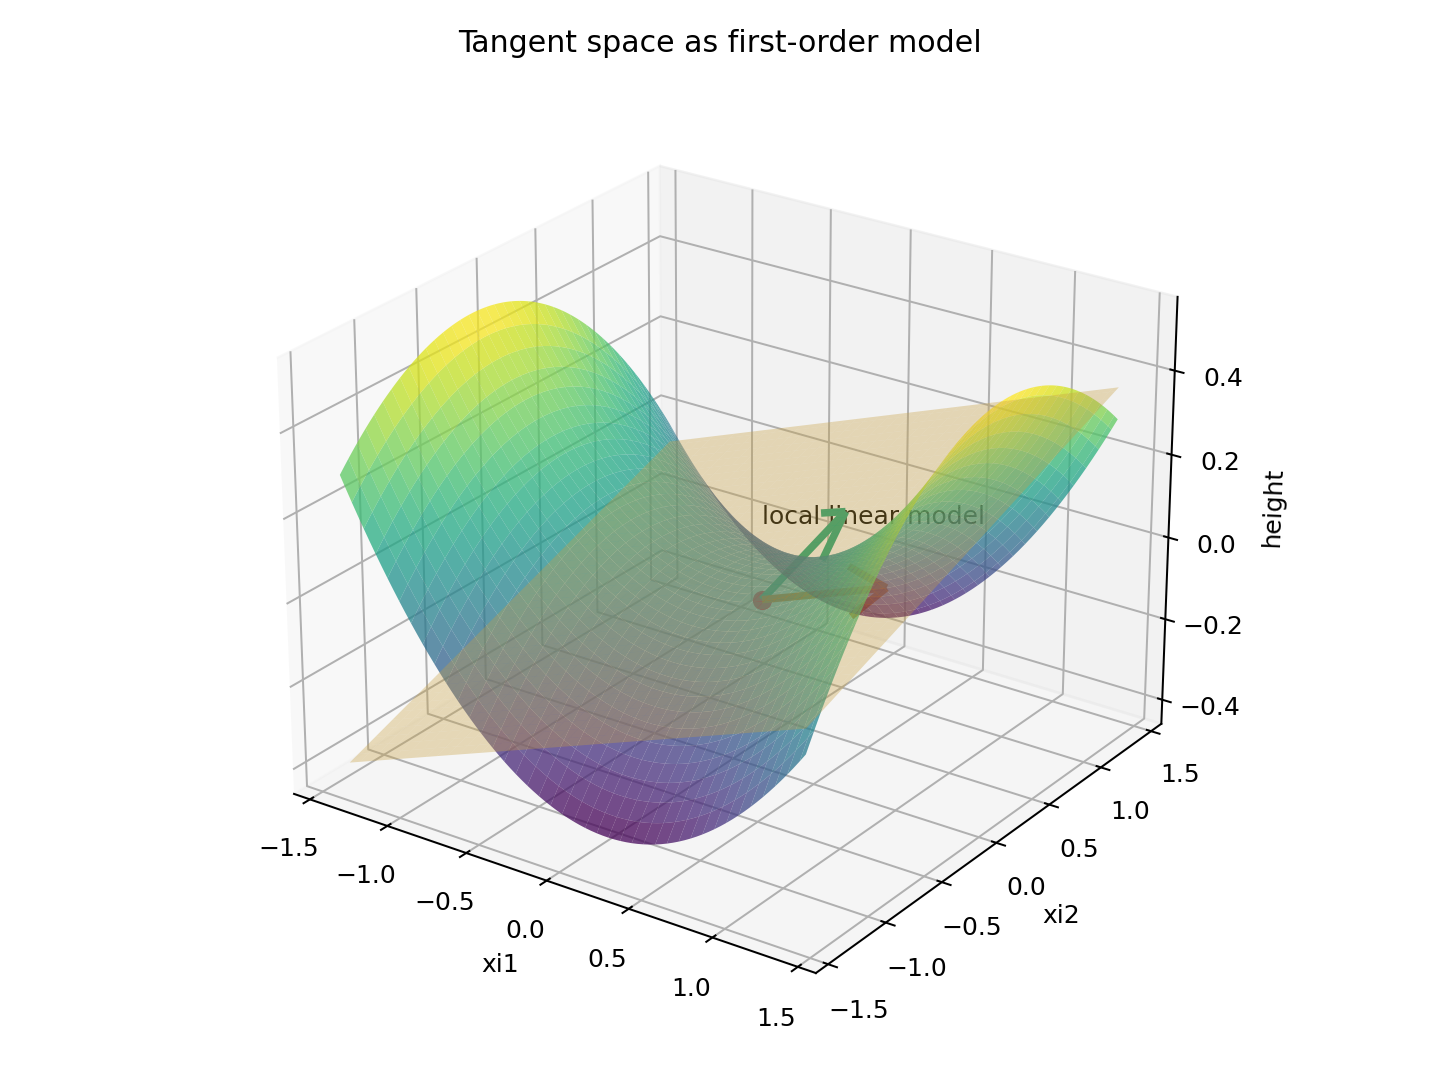

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-05/tangent_plane_metric.png')

In [2]:
display_artifact('tangent_plane_metric.png')

In [3]:

def _sphere_point(th, ph):
    return np.array([np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)])

def _sphere_basis(th, ph):
    return np.array([np.cos(th)*np.cos(ph), np.cos(th)*np.sin(ph), -np.sin(th)]), np.array([-np.sin(ph), np.cos(ph), 0.0])

def regenerate_visual_artifacts():
    # Tangent plane artifact.
    u=np.linspace(-1.4,1.4,80); v=np.linspace(-1.4,1.4,80); U,V=np.meshgrid(u,v)
    Z=.25*U**2-.18*V**2+.08*U*V; u0,v0=.35,-.25; z0=.25*u0*u0-.18*v0*v0+.08*u0*v0
    du=.5*u0+.08*v0; dv=-.36*v0+.08*u0; T=z0+du*(U-u0)+dv*(V-v0)
    fig=plt.figure(figsize=(8,6)); ax=fig.add_subplot(111,projection='3d')
    ax.plot_surface(U,V,Z,cmap='viridis',alpha=.75,linewidth=0); ax.plot_surface(U,V,T,color='#f2c14e',alpha=.35,linewidth=0)
    ax.scatter([u0],[v0],[z0],color='crimson',s=45); base=np.array([u0,v0,z0])
    for vec,color in [(np.array([1,0,du]),'#d95f02'),(np.array([0,1,dv]),'#1b9e77')]:
        vec=vec/np.linalg.norm(vec)*.75; ax.quiver(*base,*vec,color=color,linewidth=3)
    ax.text(u0,v0,z0+.18,'local linear model'); ax.set_xlabel('xi1'); ax.set_ylabel('xi2'); ax.set_zlabel('height')
    ax.set_title('Tangent space as first-order model'); ax.view_init(25,-55); fig.tight_layout(); fig.savefig(ARTIFACT_DIR/'tangent_plane_metric.png',dpi=180); plt.close(fig)

    # Metric ellipses for the sphere metric.
    fig,ax=plt.subplots(figsize=(8,5.4))
    for x,th in zip([0,2.6,5.2],[.45,.9,1.3]):
        ax.add_patch(Ellipse((x,0),2/np.sin(th),2,edgecolor='#355070',facecolor='#b8d8d8',alpha=.45,lw=2))
        ax.arrow(x,0,.75,0,head_width=.06,length_includes_head=True,color='#d95f02'); ax.arrow(x,0,0,.75,head_width=.06,length_includes_head=True,color='#1b9e77')
        ax.text(x,-1.35,f'theta={th:.2f}\ng_phi_phi={np.sin(th)**2:.2f}',ha='center')
    ax.set_aspect('equal'); ax.set_ylim(-1.8,1.45); ax.set_xlim(-1.6,6.9); ax.set_title('Metric tensor as local measuring device')
    ax.set_xlabel('coordinate increment dphi'); ax.set_ylabel('coordinate increment dtheta'); fig.tight_layout(); fig.savefig(ARTIFACT_DIR/'metric_ellipses.png',dpi=180); plt.close(fig)

    # Parallel transport around a loop on the sphere, discretized in ambient R3.
    def segment(th0,ph0,th1,ph1,V,n=80):
        pts=[]; vecs=[]; prev=_sphere_point(th0,ph0)
        for s in np.linspace(0,1,n+1)[1:]:
            th=th0+s*(th1-th0); ph=ph0+s*(ph1-ph0); cur=_sphere_point(th,ph); dX=cur-prev
            V=V-np.dot(V,dX)*cur; V=V-np.dot(V,cur)*cur; V=V/np.linalg.norm(V)
            pts.append(cur.copy()); vecs.append(V.copy()); prev=cur
        return np.array(pts),np.array(vecs),V
    th0,ph0=1.05,.15; dth,dph=.42,.85; V0=_sphere_basis(th0,ph0)[1]; V=V0.copy(); allp=[]; allv=[]
    corners=[(th0,ph0),(th0+dth,ph0),(th0+dth,ph0+dph),(th0,ph0+dph),(th0,ph0)]
    for (a,b),(c,d) in zip(corners[:-1],corners[1:]):
        p,v,V=segment(a,b,c,d,V); allp.append(p); allv.append(v)
    pts=np.vstack(allp); vec=np.vstack(allv); uu=np.linspace(0,2*np.pi,80); vv=np.linspace(0,np.pi,40)
    X=np.outer(np.cos(uu),np.sin(vv)); Y=np.outer(np.sin(uu),np.sin(vv)); Z=np.outer(np.ones_like(uu),np.cos(vv))
    fig=go.Figure(); fig.add_surface(x=X,y=Y,z=Z,opacity=.28,colorscale='Blues',showscale=False)
    fig.add_trace(go.Scatter3d(x=pts[:,0],y=pts[:,1],z=pts[:,2],mode='lines',line=dict(color='crimson',width=6),name='closed loop'))
    for k in np.linspace(0,len(pts)-1,12,dtype=int):
        p=pts[k]; q=p+.18*vec[k]; fig.add_trace(go.Scatter3d(x=[p[0],q[0]],y=[p[1],q[1]],z=[p[2],q[2]],mode='lines',line=dict(color='black',width=4),showlegend=False))
    p0=_sphere_point(th0,ph0); q0=p0+.28*V0; q1=p0+.28*V
    fig.add_trace(go.Scatter3d(x=[p0[0],q0[0]],y=[p0[1],q0[1]],z=[p0[2],q0[2]],mode='lines',line=dict(color='green',width=8),name='initial vector'))
    fig.add_trace(go.Scatter3d(x=[p0[0],q1[0]],y=[p0[1],q1[1]],z=[p0[2],q1[2]],mode='lines',line=dict(color='orange',width=8),name='after loop'))
    fig.update_layout(title='Parallel transport around a loop on the sphere',scene=dict(aspectmode='data'),margin=dict(l=0,r=0,t=45,b=0)); fig.write_html(ARTIFACT_DIR/'parallel_transport_sphere.html',include_plotlyjs='cdn')
    holonomy_angle=float(np.arccos(np.clip(np.dot(V0,V),-1,1)))

    # Curvature loop schematic.
    fig,ax=plt.subplots(figsize=(7,5.2)); P=np.array([0,0]); Q=np.array([2.4,.25]); S=np.array([.35,1.65]); Rr=Q+S
    poly=np.vstack([P,Q,Rr,S,P]); ax.plot(poly[:,0],poly[:,1],color='#355070',lw=2)
    for name,pnt in [('P',P),('Q',Q),('R',Rr),('S',S)]: ax.text(pnt[0]+.05,pnt[1]+.06,name,fontsize=12,weight='bold')
    ax.arrow(P[0],P[1],Q[0],Q[1],head_width=.08,length_includes_head=True,color='#d95f02'); ax.arrow(P[0],P[1],S[0],S[1],head_width=.08,length_includes_head=True,color='#1b9e77')
    c=(P+Q+Rr+S)/4; ax.add_patch(FancyArrowPatch((c[0]-.55,c[1]-.05),(c[0]+.55,c[1]+.25),arrowstyle='-|>',mutation_scale=16,lw=3,color='black'))
    ax.add_patch(FancyArrowPatch((c[0]-.55,c[1]-.05),(c[0]+.42,c[1]-.05),arrowstyle='-|>',mutation_scale=16,lw=3,color='orange'))
    ax.text(.45,2.25,'curvature is detected by path-dependent transport',fontsize=12); ax.set_aspect('equal'); ax.axis('off'); fig.tight_layout(); fig.savefig(ARTIFACT_DIR/'curvature_loop.png',dpi=180); plt.close(fig)

    # Fisher metric lab image.
    fig,ax=plt.subplots(figsize=(8,5.4))
    for a in np.linspace(-.8,.8,9):
        for m in np.linspace(-2,2,9): ax.add_patch(Ellipse((m,a),.36*np.exp(a),.36/np.sqrt(2),fill=False,edgecolor='#355070',alpha=.65,lw=1))
    ax.set_title('Fisher metric on the normal family in coordinates (mu, alpha=log sigma)'); ax.set_xlabel('mu'); ax.set_ylabel('alpha')
    ax.text(-1.95,.62,'g = diag(exp(-2 alpha), 2)',bbox=dict(boxstyle='round,pad=.25',fc='white',ec='0.7')); fig.tight_layout(); fig.savefig(ARTIFACT_DIR/'gaussian_fisher_metric_lab.png',dpi=180); plt.close(fig)
    return holonomy_angle

holonomy_angle = regenerate_visual_artifacts()
print('visual artifacts regenerated')


C:\Users\rahul\AppData\Local\Temp\ipykernel_14424\1961434515.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  ax.text(-1.95,.62,'g = diag(exp(-2 alpha), 2)',bbox=dict(boxstyle='round,pad=.25',fc='white',ec='0.7')); fig.tight_layout(); fig.savefig(ARTIFACT_DIR/'gaussian_fisher_metric_lab.png',dpi=180); plt.close(fig)


visual artifacts regenerated


## 2. Riemannian Metrics

A metric is an inner product on each tangent space. In coordinates it is a positive definite matrix g_ij. On probability models, the Fisher information matrix is the metric because it is the inner product of score functions.

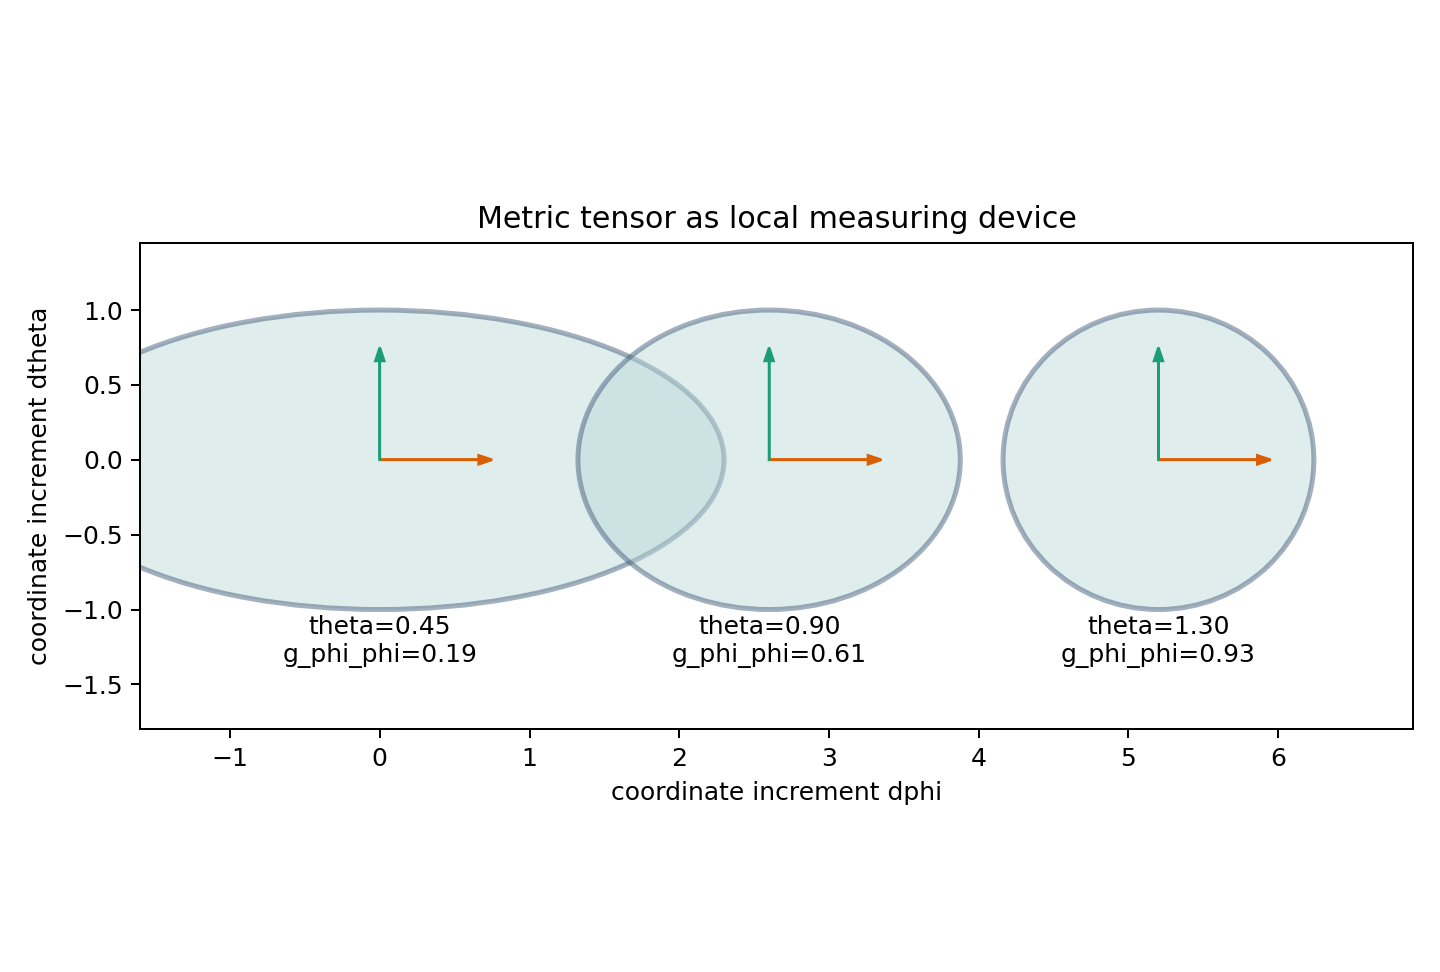

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-05/metric_ellipses.png')

In [4]:
display_artifact('metric_ellipses.png')

The unit sphere has ds^2 = dtheta^2 + sin(theta)^2 dphi^2. The same unit length has a different coordinate footprint depending on latitude.

## 3. Affine Connections

A metric compares vectors in one tangent space. An affine connection compares vectors in neighboring tangent spaces. Its coefficients Gamma describe how the coordinate basis changes; the covariant derivative corrects ordinary component derivatives by that basis motion.

## 4. Geodesics and Parallel Transport

A geodesic has tangent direction parallel to itself. Parallel transport moves a vector along a path with zero covariant derivative. In a curved manifold the result can depend on the path.

In [5]:
display_artifact('parallel_transport_sphere.html', kind='html')

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-05/parallel_transport_sphere.html')

## 5. Curvature

Riemann-Christoffel curvature is the infinitesimal failure of parallel transport around a loop to return a vector unchanged. It is also the obstruction to commuting covariant derivatives.

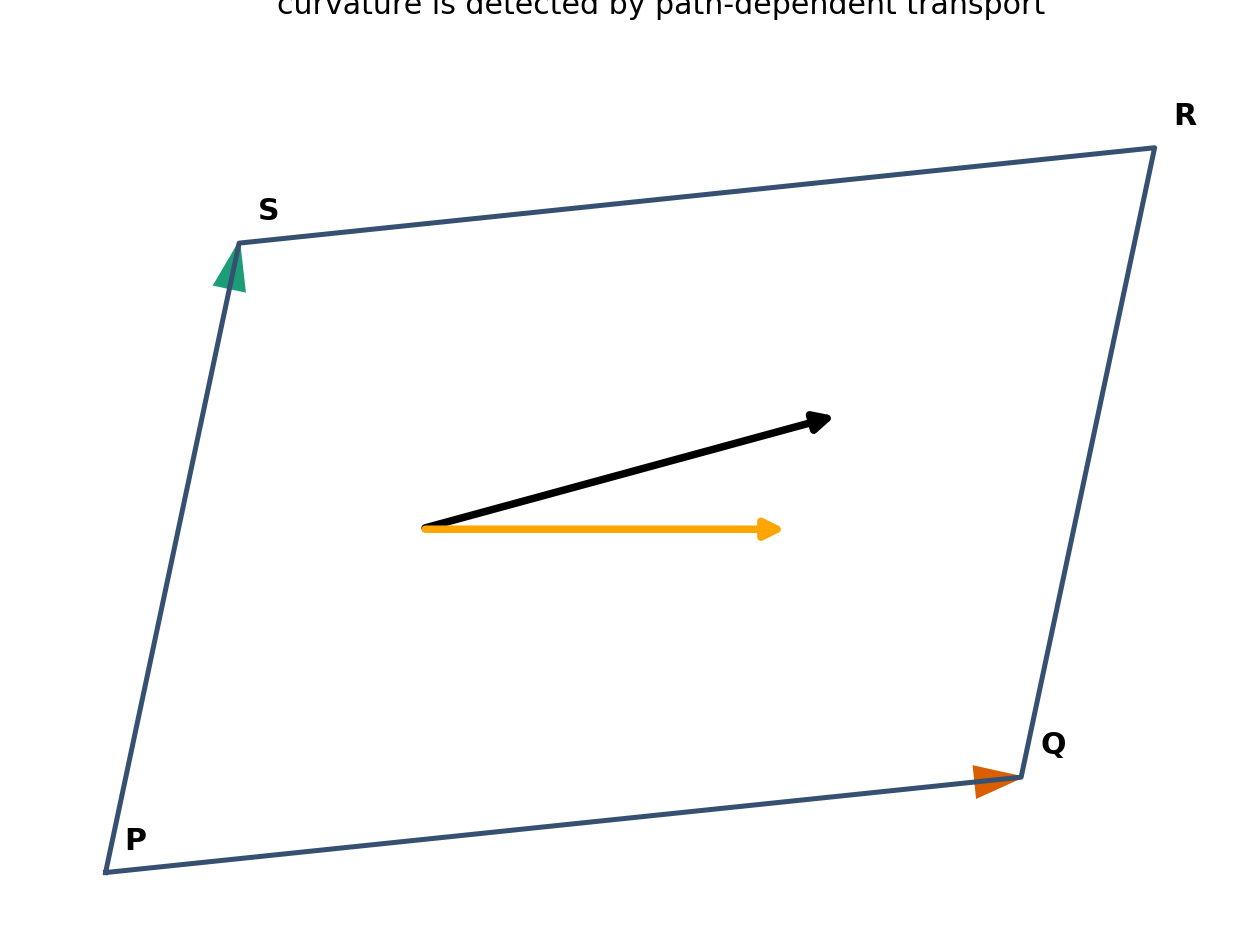

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-05/curvature_loop.png')

In [6]:
display_artifact('curvature_loop.png')

In [7]:
theta,phi=sp.symbols('theta phi', positive=True)
g=sp.Matrix([[1,0],[0,sp.sin(theta)**2]])
gi=g.inv(); coords=[theta,phi]; Gamma={}
for k in range(2):
  for i in range(2):
    for j in range(2):
      Gamma[(i,j,k)]=sp.simplify(sp.Rational(1,2)*sum(gi[k,l]*(sp.diff(g[l,j],coords[i])+sp.diff(g[l,i],coords[j])-sp.diff(g[i,j],coords[l])) for l in range(2)))
R=sp.simplify(sp.diff(Gamma[(1,1,0)],theta)-sp.diff(Gamma[(0,1,0)],phi)+sum(Gamma[(0,m,0)]*Gamma[(1,1,m)]-Gamma[(1,m,0)]*Gamma[(0,1,m)] for m in range(2)))
print('Gamma^theta_{phi phi} =', Gamma[(1,1,0)])
print('Gamma^phi_{theta phi} =', Gamma[(0,1,1)])
print('R^theta_{phi theta phi} =', R)
assert sp.simplify(Gamma[(1,1,0)] + sp.sin(theta)*sp.cos(theta)) == 0
assert sp.simplify(Gamma[(0,1,1)] - sp.cos(theta)/sp.sin(theta)) == 0
assert sp.simplify(R - sp.sin(theta)**2) == 0


Gamma^theta_{phi phi} = -sin(2*theta)/2
Gamma^phi_{theta phi} = 1/tan(theta)
R^theta_{phi theta phi} = sin(2*theta)/(2*tan(theta)) - cos(2*theta)


## 6. Applied Lab: Fisher Geometry of Normal Distributions

For the normal family in coordinates mu and alpha = log sigma, the Fisher metric is diag(exp(-2 alpha), 2). Mean motion is more expensive when the distribution is narrow, while log-scale motion has constant Fisher cost.

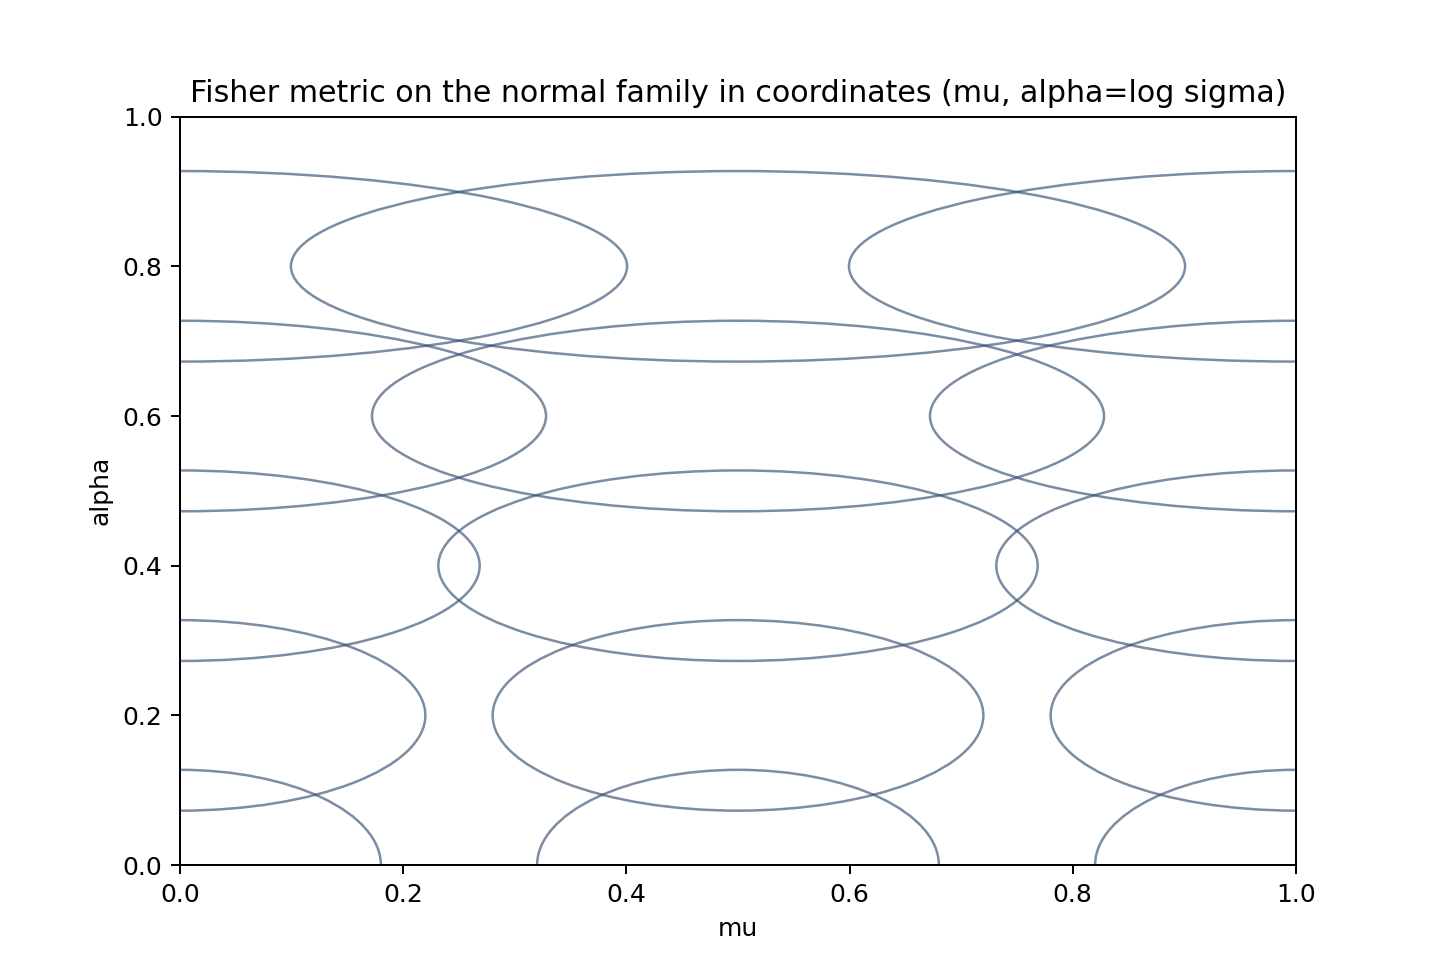

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-05/gaussian_fisher_metric_lab.png')

In [8]:
display_artifact('gaussian_fisher_metric_lab.png')

In [9]:
rng=np.random.default_rng(42); N=250000; mu=.3; alpha=.2; sigma=math.exp(alpha)
x=rng.normal(mu,sigma,N)
score_mu=(x-mu)/(sigma**2); score_alpha=-1+((x-mu)**2)/(sigma**2)
mc=np.array([[np.mean(score_mu*score_mu),np.mean(score_mu*score_alpha)],[np.mean(score_alpha*score_mu),np.mean(score_alpha*score_alpha)]])
analytic=np.array([[math.exp(-2*alpha),0],[0,2]])
err=float(np.max(np.abs(mc-analytic)))
print('Monte Carlo Fisher estimate:'); print(mc)
print('Analytic Fisher matrix:'); print(analytic)
print('max abs error =', err)
assert err < .03


Monte Carlo Fisher estimate:
[[0.67187661 0.00708839]
 [0.00708839 2.02803666]]
Analytic Fisher matrix:
[[0.67032005 0.        ]
 [0.         2.        ]]
max abs error = 0.02803665724478721


## 7. Submanifold and Embedding Curvature

A submanifold inherits tangent vectors and a metric by differentiating the embedding map. The induced connection is the ambient covariant derivative projected back to the submanifold. The normal component is embedding curvature. A cylinder bends in ambient space but has zero intrinsic RC curvature.

## Takeaways

- Tangent spaces are local linear models.
- Metrics measure tangent vectors; Fisher information is the statistical metric.
- Affine connections compare tangent spaces and define covariant derivatives.
- Geodesics and parallel transport are defined by the connection.
- Curvature is path-dependent transport around loops.
- Intrinsic curvature and embedding curvature answer different questions.

## Final Sanity Checks

In [10]:
artifact_names = [
    'tangent_plane_metric.png',
    'metric_ellipses.png',
    'parallel_transport_sphere.html',
    'curvature_loop.png',
    'gaussian_fisher_metric_lab.png',
]
sanity = {
    'chapter': '05-elements-of-differential-geometry',
    'source_orientation': {'printed_pages': '109-130', 'pdf_pages': '119-140'},
    'artifacts': {name: {'exists': (ARTIFACT_DIR/name).exists(), 'bytes': (ARTIFACT_DIR/name).stat().st_size} for name in artifact_names},
    'checks': {
        'sphere_Gamma_theta_phiphi': str(Gamma[(1,1,0)]),
        'sphere_Gamma_phi_thetaphi': str(Gamma[(0,1,1)]),
        'sphere_curvature_component_R_theta_phitheta_phi': str(R),
        'expected_R_component': 'sin(theta)**2',
        'holonomy_angle_radians_discrete': holonomy_angle,
        'gaussian_fisher_max_abs_mc_error': err,
        'gaussian_fisher_tolerance': 0.03,
    },
}
sanity['passed'] = all(v['exists'] and v['bytes'] > 1000 for v in sanity['artifacts'].values()) and err < 0.03 and sp.simplify(R - sp.sin(theta)**2) == 0
(ARTIFACT_DIR/'final_sanity.json').write_text(json.dumps(sanity, indent=2), encoding='utf-8')
display_artifact('final_sanity.json', kind='json')
assert sanity['passed']


<IPython.core.display.JSON object>

## Standalone Synthesis

The chapter focus is: Manifolds, tangent spaces, metrics, affine connections, tensors, covariant derivatives, geodesics, curvature, Levi-Civita connection, and submanifolds.

Key computational translations:

- tangent vectors are directional derivatives expressed in a chart. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- a metric turns local displacement into measurable length. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- an affine connection tells vectors how to move between tangent spaces. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- curvature records path dependence of transport. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- coordinate chart and tangent basis on a curved surface. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- metric ellipse field for a non-Cartesian coordinate system. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- geodesic shooting compared with straight chart lines. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- round-trip parallel transport revealing curvature. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 109-130; PDF pages 126-147. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-05` using the chapter's local sanity JSON naming convention.
